# Now that we have the initial data cleaning out of the way....

We will begin the preprocessing workflow, starting with the train test split.  
We won't touch our test data until the end, when we're ready to test our final, tuned model.

## Preprocessing workflow:
1. Split data
2. Impute missing values
3. Encode categorical data
4. Scale numerical data

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectPercentile, SelectFromModel, f_classif
from sklearn.linear_model import LassoCV
import seaborn as sns
import joblib
from src.transformers import CorrelationFilter
from src.features import cv_feature_selection

In [239]:
df = pd.read_csv('data/clean_data.csv', index_col=0)
df.head()

,BMI,age,has_diabetes,sex,mtb_0019013,mtb_0019128,mtb_0019529,mtb_0019819,mtb_0043320,mtb_0063639,...,mtb_1913635,mtb_1916814,mtb_1921559,mtb_1924466,mtb_1930164,mtb_1933760,mtb_1945649,mtb_1965438,mtb_1965524,mtb_1975912
0,18.664268,33.81,0.0,male,679389.1,74980.39,32937.45,38799.78,1978361.0,3310840.0,...,90860.48,206314.2,8449981.0,329809.90,5622012.0,695246.8,267273.60,590118.4,115449.10,91928.73
1,28.175977,68.56,0.0,male,1442043.0,134803.90,43889.18,41218.76,1460726.0,2881217.0,...,13075.24,127788.9,762419.7,91671.41,1530733.0,106257.0,73388.29,517381.2,53834.29,43980.13
2,22.971959,55.68,0.0,male,1561448.0,148319.80,63681.46,41428.88,1384039.0,2431488.0,...,144507.40,142956.7,8050265.0,320754.80,5200455.0,858939.3,403874.40,577710.8,186459.10,123780.90
3,21.960370,43.89,0.0,female,1850366.0,238431.50,85891.09,54732.53,1287565.0,1805011.0,...,89173.91,272361.2,4704000.0,291527.60,2649076.0,459537.8,136995.90,394305.2,92260.17,70090.77
4,40.454949,47.76,0.0,male,1643381.0,207583.80,67727.84,51707.18,1485458.0,3370410.0,...,95783.04,164424.0,4158682.0,293524.50,4448643.0,394870.9,106240.70,515005.4,81546.21,99473.02


In [240]:
y_var = 'has_diabetes'
X = df.drop(columns=y_var)
y = df[y_var]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=33)

In [241]:
X_train.shape, y_train.shape

((6518, 327), (6518,))

In [242]:
X_train.isna().sum().sort_values(ascending=False)

BMI            3
mtb_1546662    0
mtb_1590809    0
mtb_1590807    0
mtb_1590692    0
              ..
mtb_1221645    0
mtb_1221553    0
mtb_1216532    0
mtb_1209335    0
mtb_1975912    0
Length: 327, dtype: int64

## Create Preprocessing Pipeline

In [243]:
sex_col = ['sex']
bmi_age_cols = ['BMI','age']
biomarker_cols = [col for col in X_train.columns if 'mtb' in col]

In [244]:
# Data transformation plan: Biomarker columns
# Log2 transform into StandardScaler

# if any of the biomarker columns are zero or negative, they need to be handled separately
(X_train[biomarker_cols] == 0).any().any(), (X_train[biomarker_cols] < 0).any().any()

(False, False)

In [245]:
# Preprocessing pipeline
# Impute missing values
# Encode categorical data
# Scale numerical data

# Specify list of transformers for each column type
bmi_age_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'mean')),
        ('scaler', StandardScaler())
    ]
)

biomarker_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'mean')),
        ('log2_transform', FunctionTransformer(np.log2)),
        ('variance', VarianceThreshold(threshold=0.1)),
        ('scaler', StandardScaler())
    ]
)

sex_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('encoder' , OrdinalEncoder())
    ]
)

# Wrap the pipeline
preprocessor = ColumnTransformer(
    transformers = [
        ('biomarkers', biomarker_transformer, biomarker_cols),
        ('bmi_age', bmi_age_transformer, bmi_age_cols),
        ('sex', sex_transformer, sex_col)
    ]
)

In [246]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('biomarkers',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('log2_transform',
                                                  FunctionTransformer(func=<ufunc 'log2'>)),
                                                 ('variance',
                                                  VarianceThreshold(threshold=0.1)),
                                                 ('scaler', StandardScaler())]),
                                 ['mtb_0019013', 'mtb_0019128', 'mtb_0019529',
                                  'mtb_0019819', 'mtb_0043320', 'mtb_0063639',
                                  'mtb_0076722', 'mtb_0076852', 'mtb_0092191...
                                  'mtb_0158021', 'mtb_0195692', 'mtb_0201958',
                                  'mtb_0201973', 'mtb_0217805', 'mtb_0227209',
                                  'mtb_0237404', 'mtb_0250194', 'mtb_0251948',
                                  'mtb_0252448', 'mtb_0252625', 'mtb_0252641', ...]),
                                ('bmi_age',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['BMI', 'age']),
                                ('sex',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder())]),
                                 ['sex'])])

In [247]:
preprocessor.transform(X_train)

array([[ 0.34836377,  0.4087269 , -0.58960034, ...,  0.69351713,
        -1.45776626,  0.        ],
       [ 0.18095496,  0.14963377, -0.0905906 , ..., -0.69628222,
        -0.83519031,  1.        ],
       [ 0.16202828,  0.97485462,  0.76419355, ...,  0.86600461,
         1.23038681,  1.        ],
       ...,
       [-0.40091155, -0.44623548,  1.65219903, ...,  0.04226214,
         1.24490085,  1.        ],
       [-0.09684392, -0.75222008,  0.97471003, ...,  0.51209762,
        -0.69004991,  1.        ],
       [ 0.20353743,  0.42259814,  0.55585468, ..., -1.30640253,
        -1.3248482 ,  0.        ]])

# Create feature selection pipeline  
filtration strategy:
1. VarianceThreshold - drops biomarkers with little to no variation across subjects. This is done BEFORE scaling with StandardScaler(), since the scaler brings all variances to 1
2. correlation filter - removes redundant biomarkers, prevents multicollinearity
3. SelectPercentile - use ANOVA F-score to keep genes whose expression differs most between classes
4. LassoCV - penalizes weak predictors towards zero

Perform cross-validation on this entire pipeline to select the strongest features 

In [249]:
selector = Pipeline(
    steps = [
        ('correlation', CorrelationFilter(threshold=0.9)), # handle highly correlated features
        ('univariate', SelectPercentile(f_classif, percentile=10)), # keep top 10% by F-score
        ('lasso', SelectFromModel(LassoCV(cv=5, max_iter=5000)))
    ]
)

In [250]:
preprocess_and_select = Pipeline(
    steps = [
        ('preprocess', preprocessor),
        ('select', selector)
    ]
)

In [251]:
preprocess_and_select.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('biomarkers',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('log2_transform',
                                                                   FunctionTransformer(func=<ufunc 'log2'>)),
                                                                  ('variance',
                                                                   VarianceThreshold(threshold=0.1)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['mtb_0019013', 'mtb_0019128',
                                                   'mtb_0019529', 'mtb_0019819',
                                                   'mtb_0043320', 'mtb_0063639',
                                                   'mtb_00767...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BMI', 'age']),
                                                 ('sex',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['sex'])])),
                ('select',
                 Pipeline(steps=[('correlation', CorrelationFilter()),
                                 ('univariate', SelectPercentile()),
                                 ('lasso',
                                  SelectFromModel(estimator=LassoCV(cv=5,
                                                                    max_iter=5000)))]))])

In [252]:
X_train_reduced = preprocess_and_select.transform(X_train)

In [253]:
X_train_reduced.shape, X_train.shape

((6518, 23), (6518, 327))

# See what survived

### First, look for biomarkers that survived the intial variance filter (after log2 scaling, before StandardScaler)

In [254]:
var_step = preprocessor.named_transformers_['biomarkers'].named_steps['variance']
biomarkers_after_var = np.array(biomarker_cols)[var_step.get_support()]
print(f"Biomarkers before variance filter: {len(biomarker_cols)}")
print(f"Biomarkers after variance filter: {len(biomarkers_after_var)}")
print(f"Biomarkers removed: {len(biomarker_cols) - len(biomarkers_after_var)}")

Biomarkers before variance filter: 324
Biomarkers after variance filter: 254
Biomarkers removed: 70


Inspect the variances

In [255]:
variance_values = pd.Series(
    var_step.variances_,
    index = biomarker_cols
)
variance_values.sort_values() # automatically views 5 lowest and 5 highest variances

mtb_0970174    0.006935
mtb_0972202    0.007381
mtb_0970177    0.007866
mtb_1272352    0.008875
mtb_1391826    0.009548
                 ...   
mtb_0313547    1.194482
mtb_1766826    1.295314
mtb_1772798    1.327115
mtb_1028495    2.695009
mtb_1177078    3.907058
Length: 324, dtype: float64

<Axes: ylabel='Count'>

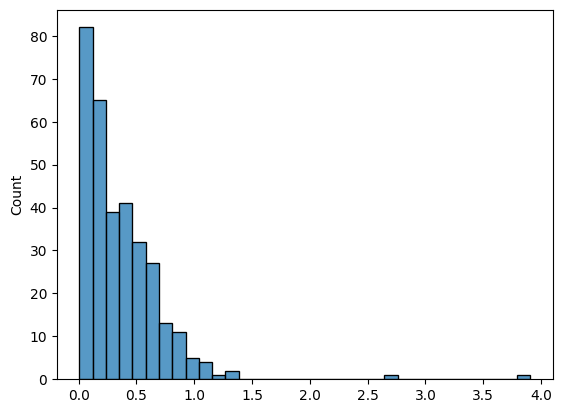

In [256]:
sns.histplot(variance_values)

From the above histogram, we can see that the majority of variances of the log2frequencies of the biomarkers are between 0 and 0.5, but there are two distinct outliers (mtb_1028495 = 2.7 and mtb_1177078 = 3.9), suggesting that they could be important in the final model. Will they survive the rest of the feature selection pipeline?

### Now that we've shaved off a few biomarkers, we can apply the StandardScaler() on the surviving genes, and look at the scores for the rest of the feature selection pipeline

In [257]:
# add the BMI, Age, and Sex columns back into the selector
combined_names = np.array(
    list(biomarkers_after_var) + bmi_age_cols + sex_col
)
print(f"{len(combined_names)} features entering selector")

257 features entering selector


In [258]:
# Capture outputs at each stage of funnel

sel = preprocess_and_select.named_steps['select']

# Correlation filter
cor_mask = ~np.isin(np.arange(len(combined_names)),
                     sel.named_steps['correlation'].drop_cols_)
after_cor = combined_names[cor_mask]

# Univariate
uni_mask  = sel.named_steps['univariate'].get_support()
after_uni = after_cor[uni_mask]

# Lasso
las_mask  = sel.named_steps['lasso'].get_support()
final_features = after_uni[las_mask]

In [259]:
# build summary table 
univariate_scores = pd.DataFrame({
    'f_score': sel.named_steps['univariate'].scores_,
    'p_value': sel.named_steps['univariate'].pvalues_,
}, index=after_cor)

lasso_coefs = pd.Series(
    sel.named_steps['lasso'].estimator_.coef_.flatten(),
    index=after_uni
)

summary = pd.DataFrame(index=final_features)
summary['variance'] = variance_values.reindex(final_features)  # expect NaN for age/bmi/sex
summary['f_score'] = univariate_scores['f_score'].reindex(final_features)
summary['p_value'] = univariate_scores['p_value'].reindex(final_features)
summary['lasso_coef'] = lasso_coefs.reindex(final_features)
summary['abs_coef'] = summary['lasso_coef'].abs()
summary = summary.sort_values('abs_coef', ascending=False)

print("\nFinal selected features:")
print(summary.round(4))


Final selected features:
             variance   f_score  p_value  lasso_coef  abs_coef
BMI               NaN  790.9588      0.0      0.0741    0.0741
mtb_1567645    0.3091  252.2047      0.0     -0.0274    0.0274
age               NaN  268.0967      0.0      0.0273    0.0273
mtb_0825561    0.5316   94.1663      0.0      0.0240    0.0240
mtb_1254618    0.1909   95.7509      0.0      0.0194    0.0194
mtb_0963388    0.6521  137.1467      0.0     -0.0168    0.0168
mtb_1311918    0.6831  318.0376      0.0     -0.0147    0.0147
mtb_1221553    0.6028   97.2562      0.0     -0.0140    0.0140
mtb_0522146    0.2597  116.4128      0.0      0.0128    0.0128
mtb_1374393    0.1273  165.1774      0.0      0.0121    0.0121
mtb_0969469    0.7982  131.6432      0.0      0.0109    0.0109
mtb_1425338    0.1496  109.4344      0.0     -0.0106    0.0106
mtb_1766602    0.2160  165.4214      0.0     -0.0105    0.0105
mtb_1827483    0.8582   95.2616      0.0     -0.0100    0.0100
mtb_1897069    0.3184  104.77

## Final selected features:
We've successfully narrowed down the features from 327 to 23. Of these 21 are biomarkers, and the other two are BMI and age. Intuitively, it makes sense that BMI is the most powerful feature according to this selection pipeline. Age is the third most powerful, after one particular biomarker. However, we should really perform cross-validation to ensure that these features are consistently informative

# CROSS-VALIDATION of feature selection pipeline

In [279]:
non_biomarker_cols = bmi_age_cols + sex_col
n_splits = 5
fold_summaries, stability = cv_feature_selection(
    pipeline = preprocess_and_select, 
    X = X_train, 
    y = y_train,
    biomarker_cols = biomarker_cols,
    non_biomarker_cols=non_biomarker_cols,
    n_splits=n_splits,
    random_state=33
)

Fold 1: 23 features selected → ['mtb_0522146', 'mtb_0690120', 'mtb_0825561', 'mtb_0866690', 'mtb_0963388', 'mtb_0969469', 'mtb_0985311', 'mtb_1151279', 'mtb_1221553', 'mtb_1311918', 'mtb_1374393', 'mtb_1425338', 'mtb_1567645', 'mtb_1612213', 'mtb_1766602', 'mtb_1793240', 'mtb_1810358', 'mtb_1827483', 'mtb_1897069', 'mtb_1911986', 'mtb_1933760', 'BMI', 'age']
Fold 2: 22 features selected → ['mtb_0522146', 'mtb_0690120', 'mtb_0963388', 'mtb_0969469', 'mtb_0985311', 'mtb_1151279', 'mtb_1254618', 'mtb_1311918', 'mtb_1374393', 'mtb_1425338', 'mtb_1567645', 'mtb_1574298', 'mtb_1612158', 'mtb_1766602', 'mtb_1810358', 'mtb_1827483', 'mtb_1888866', 'mtb_1897069', 'mtb_1911986', 'mtb_1933760', 'BMI', 'age']
Fold 3: 20 features selected → ['mtb_0522146', 'mtb_0866690', 'mtb_0963388', 'mtb_0969469', 'mtb_0985311', 'mtb_1221553', 'mtb_1311918', 'mtb_1374393', 'mtb_1425338', 'mtb_1508092', 'mtb_1567645', 'mtb_1612213', 'mtb_1766602', 'mtb_1793240', 'mtb_1827483', 'mtb_1857284', 'mtb_1865064', 'mtb_1

In [280]:
fold_summaries

[             fold  variance     f_score        p_value  lasso_coef  abs_coef
 feature                                                                     
 BMI             1       NaN  608.471785  3.677150e-127    0.074606  0.074606
 mtb_0825561     1  0.531310   74.520673   7.867850e-18    0.025082  0.025082
 age             1       NaN  195.181873   1.424307e-43    0.024924  0.024924
 mtb_1567645     1  0.312068  196.846987   6.358792e-44   -0.024520  0.024520
 mtb_1311918     1  0.671417  264.245814   5.333166e-58   -0.016436  0.016436
 mtb_0963388     1  0.653909   98.510363   5.168127e-23   -0.014696  0.014696
 mtb_0522146     1  0.259247   87.377135   1.298915e-20    0.014238  0.014238
 mtb_1221553     1  0.591933   77.015932   2.264172e-18   -0.012894  0.012894
 mtb_1425338     1  0.149388   91.316380   1.833962e-21   -0.012749  0.012749
 mtb_1374393     1  0.127189  128.607280   1.826144e-29    0.011854  0.011854
 mtb_0969469     1  0.795422   92.681290   9.312053e-22    0.011

In [281]:
# check out the results for each CV fold:
for i, fold_df in enumerate(fold_summaries, 1):
    print(f"Fold: {i}")
    print(fold_df.round(4))

Fold: 1
             fold  variance   f_score  p_value  lasso_coef  abs_coef
feature                                                             
BMI             1       NaN  608.4718      0.0      0.0746    0.0746
mtb_0825561     1    0.5313   74.5207      0.0      0.0251    0.0251
age             1       NaN  195.1819      0.0      0.0249    0.0249
mtb_1567645     1    0.3121  196.8470      0.0     -0.0245    0.0245
mtb_1311918     1    0.6714  264.2458      0.0     -0.0164    0.0164
mtb_0963388     1    0.6539   98.5104      0.0     -0.0147    0.0147
mtb_0522146     1    0.2592   87.3771      0.0      0.0142    0.0142
mtb_1221553     1    0.5919   77.0159      0.0     -0.0129    0.0129
mtb_1425338     1    0.1494   91.3164      0.0     -0.0127    0.0127
mtb_1374393     1    0.1272  128.6073      0.0      0.0119    0.0119
mtb_0969469     1    0.7954   92.6813      0.0      0.0111    0.0111
mtb_1933760     1    0.4598   78.3825      0.0     -0.0086    0.0086
mtb_1766602     1    0.216

In [282]:
# How stable are each of the selected biomarkers? ie how often do they appear out of the K number of cross-validation folds?

stability.round(4)

,times_selected,mean_f_score,std_f_score,mean_lasso_coef,std_lasso_coef,mean_abs_coef,mean_variance,selected_pct
feature,,,,,,,,
BMI,5,633.1887,27.8151,0.0766,0.0045,0.0766,NaN,100
age,5,214.6783,13.7544,0.0296,0.0033,0.0296,NaN,100
mtb_1567645,5,201.7822,6.0891,-0.0251,0.0030,0.0251,0.3091,100
mtb_0963388,5,109.9526,10.9187,-0.0161,0.0022,0.0161,0.6520,100
mtb_1311918,5,254.6498,16.4620,-0.0137,0.0034,0.0137,0.6830,100
mtb_0522146,5,93.2138,6.6628,0.0115,0.0042,0.0115,0.2597,100
mtb_0969469,5,105.6668,13.4190,0.0115,0.0017,0.0115,0.7982,100
mtb_1425338,5,87.7894,9.6852,-0.0096,0.0039,0.0096,0.1496,100
mtb_1897069,5,83.9869,7.7166,-0.0093,0.0048,0.0093,0.3184,100


Finally, select the biomarkers that appeared in 80% or more of CV splits:

In [319]:
stable_features = stability.index[stability.selected_pct >= 80].tolist()
stable_features

['BMI',
 'age',
 'mtb_1567645',
 'mtb_0963388',
 'mtb_1311918',
 'mtb_0522146',
 'mtb_0969469',
 'mtb_1425338',
 'mtb_1897069',
 'mtb_1827483',
 'mtb_1766602',
 'mtb_0985311',
 'mtb_1374393',
 'mtb_1221553']

### Go back and build a lean preprocessor with only the features that survived cross-validation

In [298]:
# select only the features that survived cross-validation
stable_biomarkers = [f for f in stable_features if f in biomarker_cols]
stable_bmi_age = [f for f in stable_features if f in bmi_age_cols]
stable_sex = [f for f in stable_features if f in sex_col]

In [321]:
stable_biomarkers

['mtb_1567645',
 'mtb_0963388',
 'mtb_1311918',
 'mtb_0522146',
 'mtb_0969469',
 'mtb_1425338',
 'mtb_1897069',
 'mtb_1827483',
 'mtb_1766602',
 'mtb_0985311',
 'mtb_1374393',
 'mtb_1221553']

In [322]:
bmi_age_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'mean')),
        ('scaler', StandardScaler())
    ]
)

biomarker_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'mean')),
        ('log2_transform', FunctionTransformer(np.log2)),
        ('scaler', StandardScaler())
    ]
)

sex_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('encoder' , OrdinalEncoder(categories = [['male','female']]))
    ]
)

# Wrap the pipeline
preprocessor = ColumnTransformer(
    transformers = [
        ('biomarkers', biomarker_transformer, stable_biomarkers),
        ('bmi_age', bmi_age_transformer, stable_bmi_age),
        ('sex', sex_transformer, stable_sex)
    ] if stable_sex else [
        ('biomarkers', biomarker_transformer, stable_biomarkers),
        ('bmi_age', bmi_age_transformer, stable_bmi_age)
    ]
)

In [323]:
preprocessor.fit(X_train[stable_biomarkers + stable_bmi_age + stable_sex], y_train)

ColumnTransformer(transformers=[('biomarkers',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('log2_transform',
                                                  FunctionTransformer(func=<ufunc 'log2'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['mtb_1567645', 'mtb_0963388', 'mtb_1311918',
                                  'mtb_0522146', 'mtb_0969469', 'mtb_1425338',
                                  'mtb_1897069', 'mtb_1827483', 'mtb_1766602',
                                  'mtb_0985311', 'mtb_1374393',
                                  'mtb_1221553']),
                                ('bmi_age',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['BMI', 'age'])])

# Save the preprocessor and list of features!

In [324]:
joblib.dump(preprocessor, 'data/preprocessor.pk1')
joblib.dump(stable_features, 'stable_features.pk1')

['stable_features.pk1']